# Flow depth map with PyGMT
Plots the maximum inundation depth from a `*_flowdepth.nc` file over shaded bathymetry/topography.

In [20]:
import numpy as np
import xarray as xr
import pygmt

In [21]:
base_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami'
reg = 'CT'  # CT or SR
bathy_file = f'{base_dir}/data/processed/{reg}_defbathy.nc'  # variables: x, y, z
depth_file = f'{base_dir}/data/simu/BS_4-8_manning003_extreme_ts/E00979N4372E01586N3827-BS-M809_E01517N3827_D010_S157D70R090_A006995_S075/grid3-catania_flowdepth.nc'  # max flow depth, z(lat, lon)
cptfile_bathy = f'{base_dir}/scripts/JGR/plots/extra/bathy_error.cpt'
min_depth = 0.1  # m, depths below this are not drawn

In [22]:
grid = xr.open_dataset(bathy_file)
xmin, xmax = grid['x'].min().values, grid['x'].max().values
ymin, ymax = grid['y'].min().values, grid['y'].max().values

# Flow depth grid; dry cells and depths below min_depth are masked
depth = xr.open_dataset(depth_file)['z']
grid_depth = depth.where(depth > min_depth).rename({'lon': 'x', 'lat': 'y'})
print(f'max depth {float(grid_depth.max()):.2f} m')

max depth 8.49 m


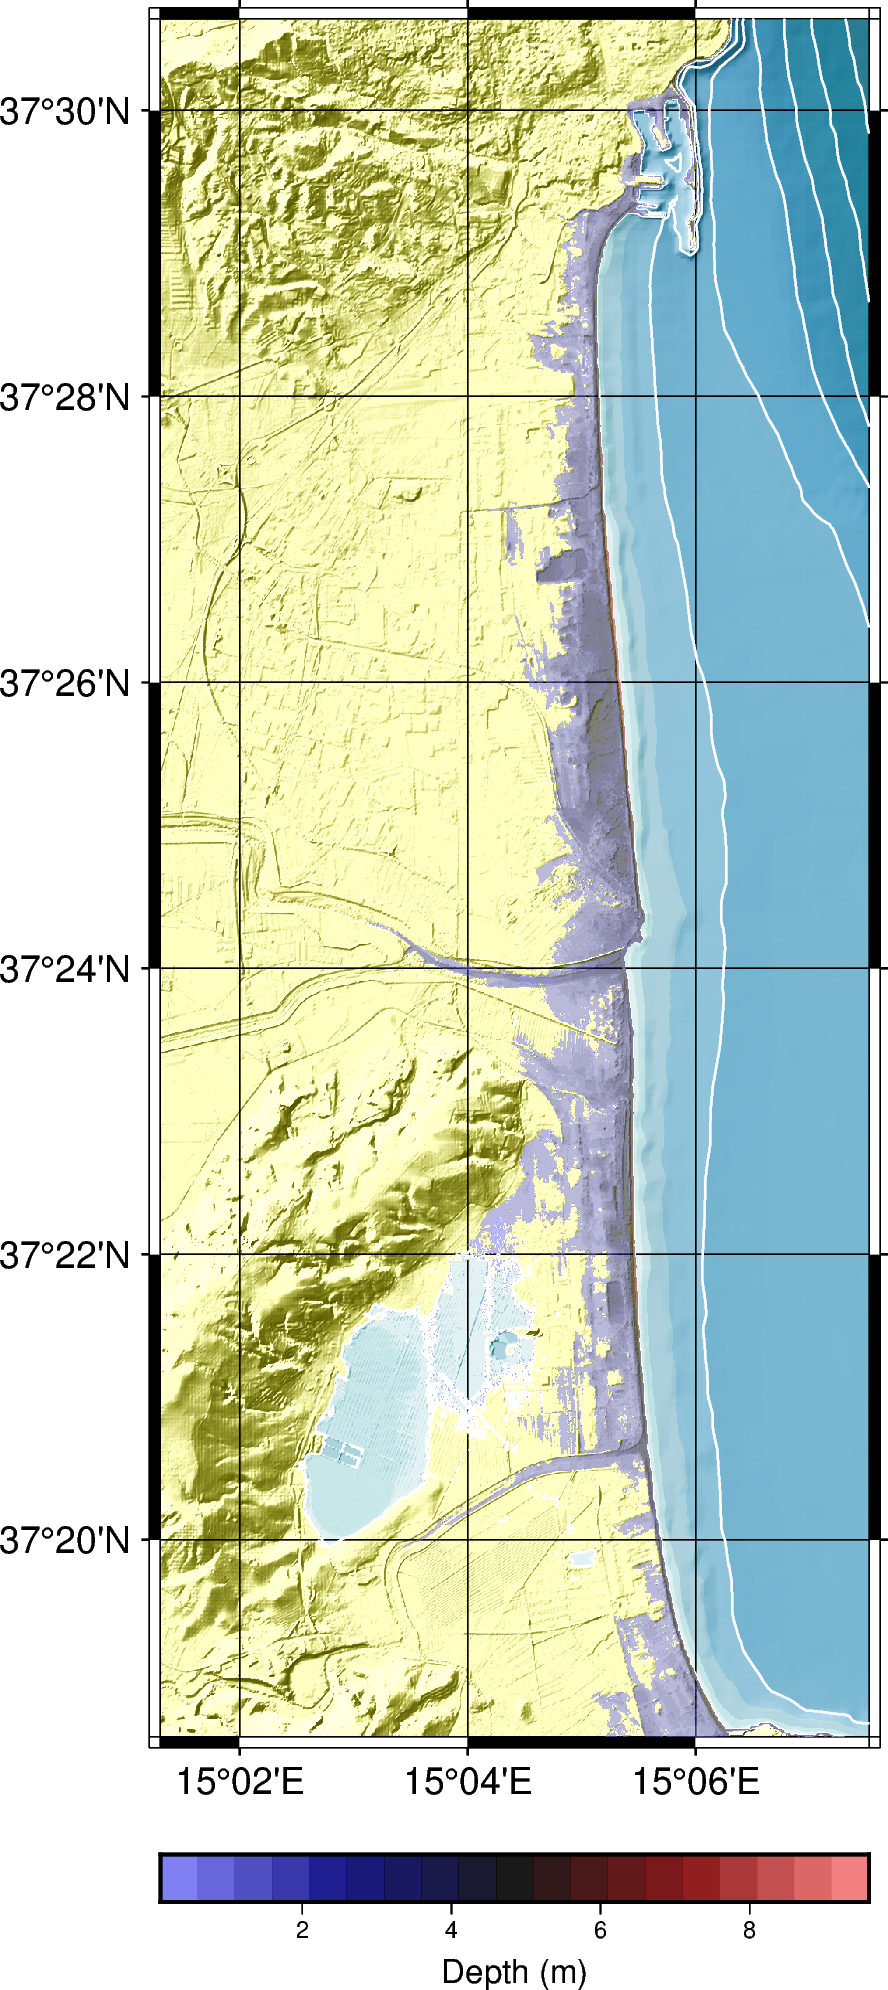

In [23]:
fig = pygmt.Figure()
pygmt.makecpt(cmap=cptfile_bathy, continuous=False)
fig.grdimage(grid['z'], cmap=True, shading=True, region=[xmin, xmax, ymin, ymax], projection='M6c',
             frame=['ag', 'x+lLongitude', 'y+lLatitude'])
fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0], projection='M6c')

pygmt.makecpt(cmap='split', series=[min_depth, 10, 0.5], transparency=10)
fig.grdimage(grid_depth, cmap=True, projection='M6c', nan_transparent=True, transparency=50)
fig.colorbar(frame=['a2', 'x+lDepth (m)'], position='JBC+w6c/0.4c+h+o0/1c')
fig.show()